In [1]:
import numpy as np
import pandas as pd
import warnings
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.decomposition import PCA


In [2]:
# Устанавливаем максимальное количество потоков для joblib
os.environ["LOKY_MAX_CPU_COUNT"] = "12"
# Подавляем предупреждения
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

### Загрузка данных

In [3]:
# Data loading

dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [4]:
dataset.shape

(23479, 500)

Text(0, 0.5, 'bit ADC')

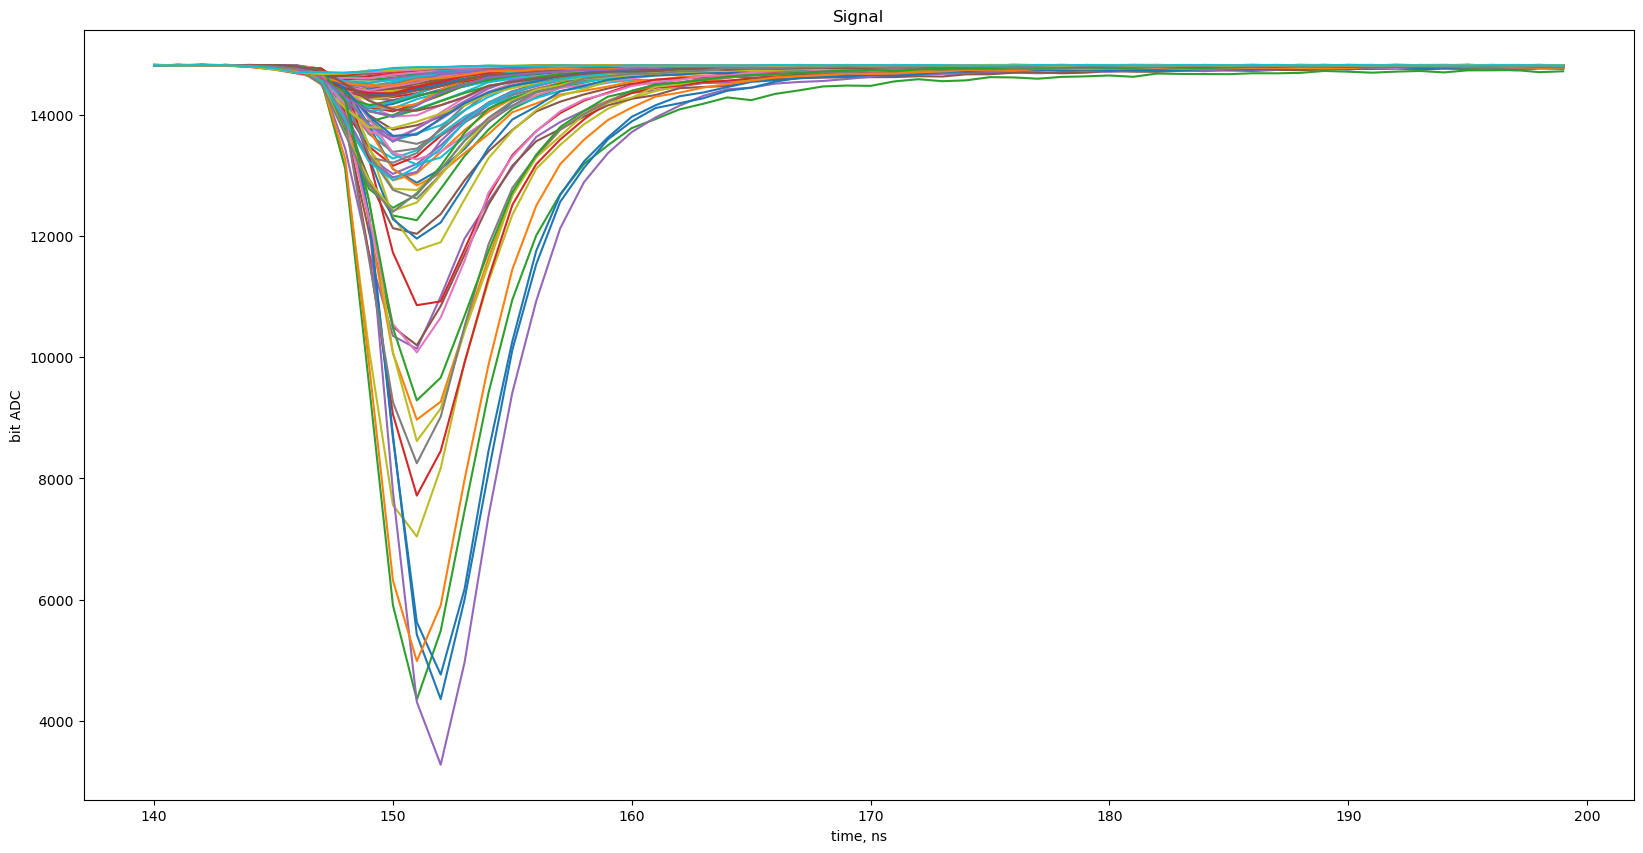

In [5]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

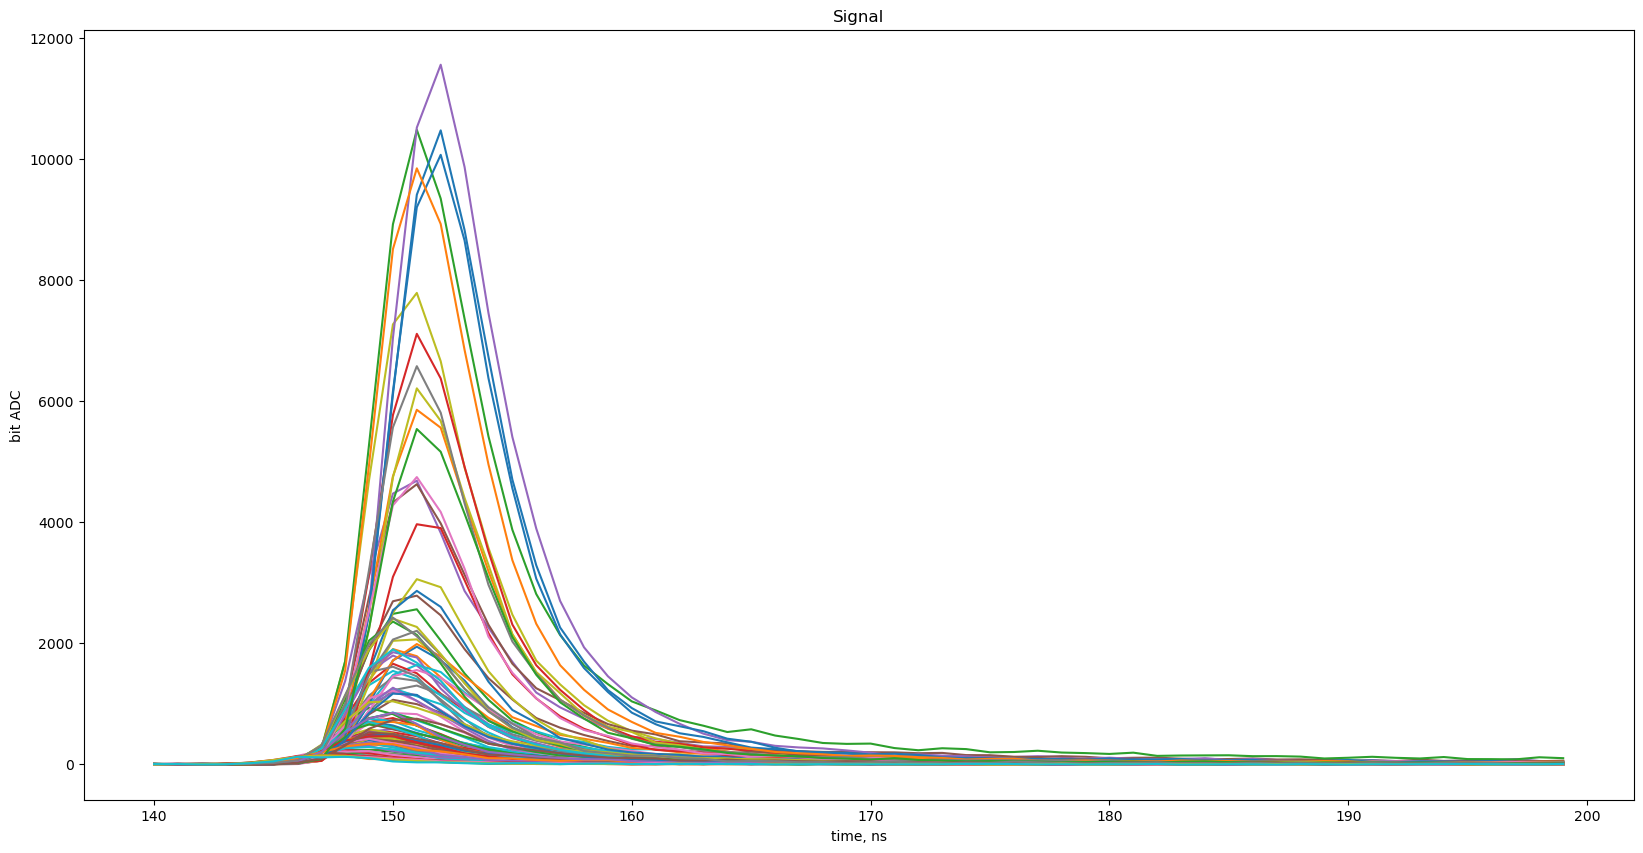

In [6]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


### Предобработка данных

In [7]:
# Анализ пропусков
missing_values = dataset.isnull().sum() 
total_rows = len(dataset) 

# Фильтруем только столбцы с пропусками
missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

missing_data

,Missing Count,Missing Percentage


##### пропусков нет

In [8]:
# Нормализуем данные
ndf = 2**14 - dataset - 1560
# Заменим все, что меньше 1 на 1
ndf = ndf.clip(lower=1)

In [9]:
ndf

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,4,1,1,2,6,4,1,2,4,4,...,1,2,9,9,7,5,4,2,4,5
1,4,2,4,1,1,2,4,2,1,3,...,1,7,1,2,1,5,4,5,2,4
2,4,4,2,1,4,1,1,5,1,1,...,4,3,4,4,6,3,1,4,4,3
3,1,2,6,1,1,2,4,2,1,4,...,1,1,2,3,4,1,4,2,1,2
4,1,9,1,3,1,4,1,1,8,3,...,4,4,1,1,1,4,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,1,1,1,6,1,1,1,1,1,1,...,1,1,1,5,1,1,2,1,1,1
23475,1,1,5,1,5,1,1,1,1,3,...,1,1,1,10,10,6,8,2,5,7
23476,2,2,1,4,1,1,1,1,4,1,...,1,7,9,7,6,7,8,5,7,4
23477,1,1,1,2,3,1,4,2,1,1,...,1,1,1,2,1,1,2,4,5,1


##### Cигналом в контексте поставленной задачи называется:

подмножество значений кривой, содержащееся между максимумом и местом,
где значение кривой начало отставать от нулевой линии на три стандартных
отклонения.

#### Сигналы с плоскими пиками нужно удалять,
 т.к. физика ппроцесса предполагает поступление энергии за короткое время, т.е. острый пикю

In [10]:
# Функция удаления сигналов с плоскими пиками
# Выбирает сигналы, у которых пиковая крутизна в заданном диапазоне меньше порога.
def select_nopeak(ndf, sharp_t, start_col=100, end_col=250):
    selected_ind = []
    # Список для плохих сигналов
    bad_signals_ind = []  

    for idx, row in ndf.iterrows():
        signal = np.log1p(row.iloc[start_col:end_col].values)
        peak_idx = signal.argmax()

        peak_amp = signal[peak_idx]
        n_left = signal[peak_idx - 1]
        n_right = signal[peak_idx + 1]

        # Сравниваем с максимальным из соседей
        n_max = min(n_left, n_right)

        # Пиковая крутизна
        if peak_amp != 0:
            peak_sharp = (peak_amp - n_max) / peak_amp
            log_peak_sharp = peak_sharp 
        else:
            log_peak_sharp = 0

        # Если логарифмированная пиковая крутизна меньше порога, добавляем в bad_signals_ind
        if log_peak_sharp < sharp_t:
            bad_signals_ind.append(idx)
        else:
            selected_ind.append(idx)

    # Выбираем сигналы с плохими пиками
    bad_signals = ndf.loc[bad_signals_ind]
    # Выбираем сигналы с хорошими пиками
    good_signals = ndf.loc[selected_ind]
    
    return good_signals, bad_signals

In [11]:
# Применяем функцию для получения хороших и плохих сигналов
good_signals, bad_signals = select_nopeak(ndf, 0.004)

print(f"Количество хороших сигналов: {len(good_signals)}")
print(f"Количество плохих сигналов: {len(bad_signals)}")

Количество хороших сигналов: 23452
Количество плохих сигналов: 27


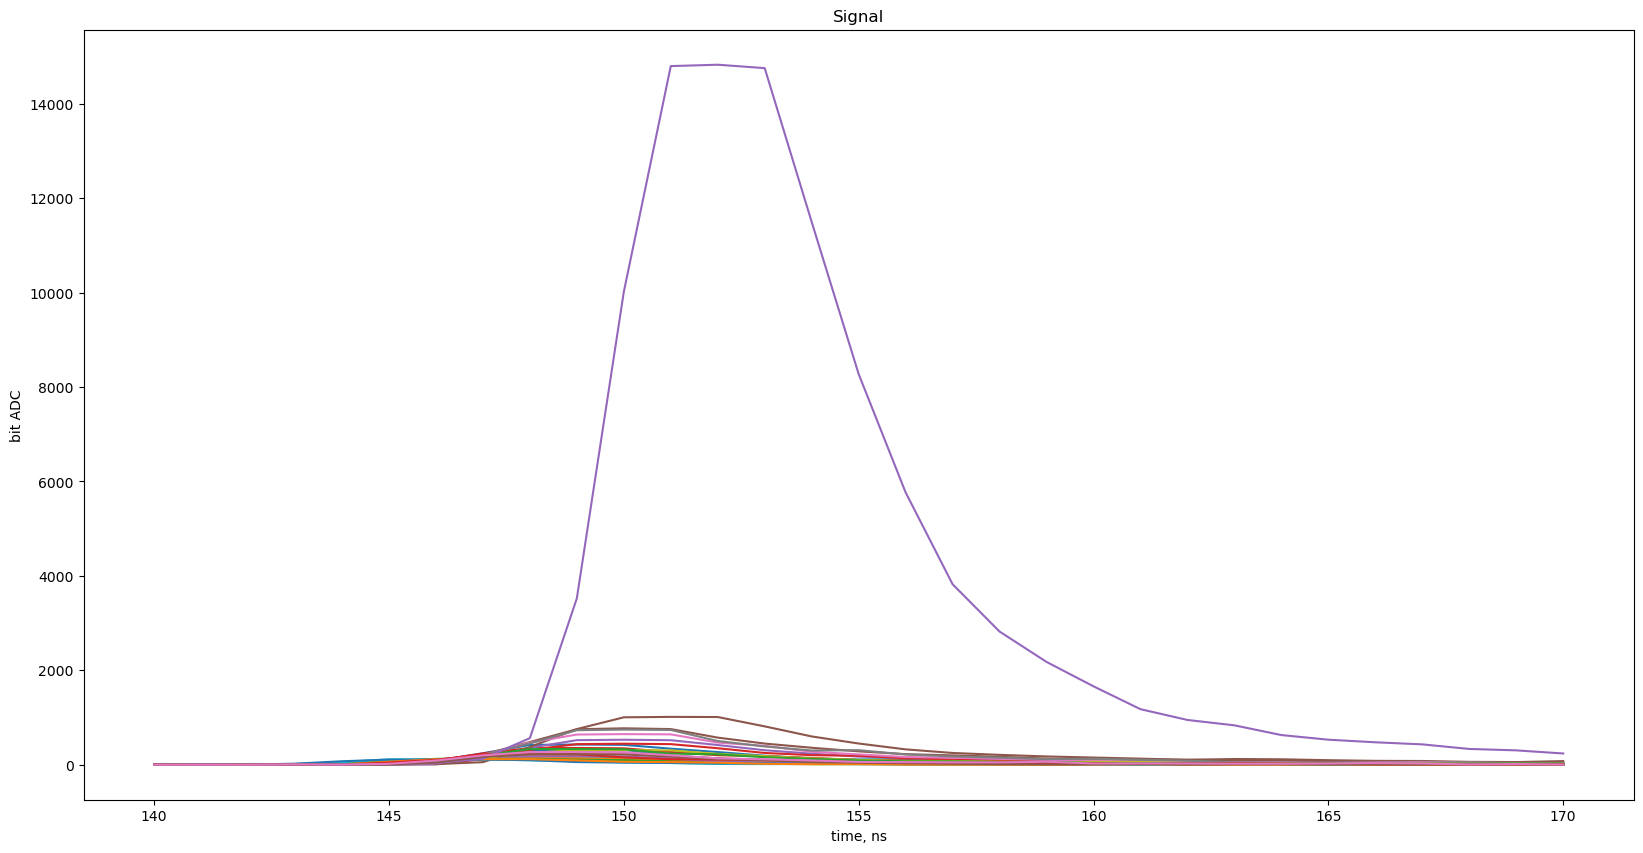

In [12]:
# Покажем на графике плохие сигналы
for i in bad_signals.index:
    ax = (ndf.loc[i,140:170]).plot(title='Signal' ,legend=None,figsize=(20,10))
    ax.set_xlabel("time, ns")
    ax.set_ylabel("bit ADC")

##### Началом сигнала будет считаться отсчёт,
отстоящий от максимума по амплитуде на определённое количество процентов
в таком случае число отсчётов,
которое будет отступаться от максимума – число,

меняющееся в зависимости от исходных данных.

In [13]:
#  Функция выделяет сигнал начиная не с пика, а с определённого смещения
def preprocess_signal(signal, shift=3, amp_percent=0.4, baseline=50, t_k=3):
    
    baseline_zone = signal[:baseline] # Участок где считается нулевая линия
    baseline_mean = np.mean(baseline_zone) # Нулевая линия
    baseline_std = np.std(baseline_zone)  # Стандартное отклонение
    t = baseline_mean + t_k * baseline_std # Порог

    peak_idx = np.argmax(signal)
    amp = signal[peak_idx]

    # Определяем начало сигнала
    target_amp = signal[peak_idx] * amp_percent
    start_idx = None
    for i in range(peak_idx + 1, len(signal)):
        if signal[i] <= target_amp:
            start_idx = i
            break
        if start_idx is None:
            start_idx = peak_idx + 1  # запасной вариант
   
    # Определяем конец сигнала
    end_idx = None
    for i in range(start_idx + 1, len(signal)):
        if signal[i] < t:
            end_idx = i
            break
    if end_idx is None:
        end_idx = len(signal)

    # Извлекаем сигнал и время
    signal_segment = signal[start_idx:end_idx]
    time_segment = np.arange(len(signal_segment))

    return baseline_mean, baseline_std, start_idx, end_idx, signal_segment, time_segment, amp

#### Теперь сформируем датасет из хороших сигналов с новыми признаками:
- area площадь под сигналом или накопленная энергия
- peak амплитуда сигнала
- peak2 максимум по выбранному диапазону остчетов

In [14]:
features = []
# сюда будем сохранять оригинальные индексы
index_list = [] 

total_signals = len(good_signals)

for idx in tqdm(good_signals.index, desc="Извлечение признаков"):
    signal = good_signals.loc[idx].values  # теперь .loc по индексу
    index_list.append(idx)  # сохраняем индекс

    # Выделение сегмента
    _, _, start_idx, end_idx, signal_segment, time_segment, peak = preprocess_signal(signal, amp_percent=0.4)

    
    peak2 = np.max(signal_segment)
    area = np.sum(signal_segment)
    area_to_peak = area / peak if peak != 0 else 0

    features.append([peak2, peak, area])

# Собираем всё в DataFrame
features_df = pd.DataFrame(features, columns=["peak2", "peak", "area"], index=index_list)

features_df.head(10)


Извлечение признаков: 100%|███████████████████████████████████████████████████| 23452/23452 [00:01<00:00, 12782.10it/s]


,peak2,peak,area
0,194,533,1128
1,551,1903,2539
2,722,2560,3436
3,188,566,1261
4,663,1796,2981
5,87,238,496
6,271,847,2530
7,52,169,308
8,598,2063,2737
9,543,1641,4457


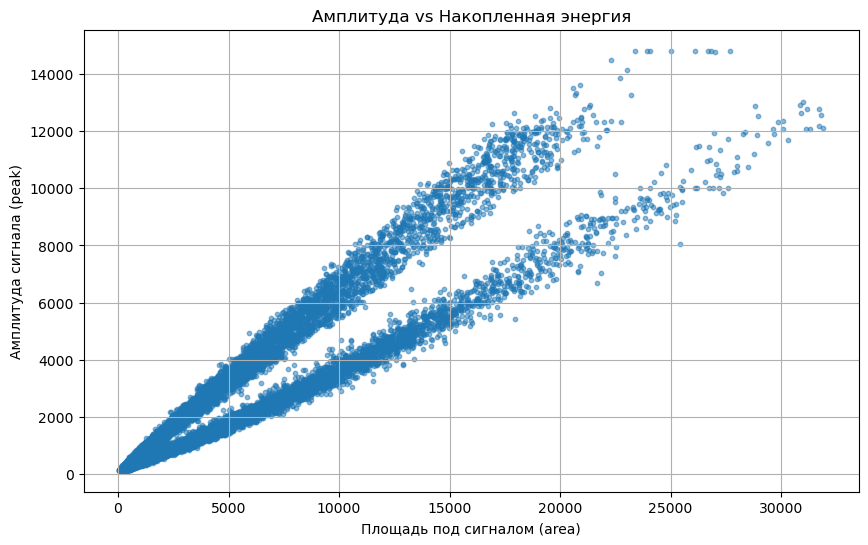

In [15]:
# Построим график амплитуды и площади
plt.figure(figsize=(10, 6))
plt.scatter(features_df['area'], features_df['peak'], alpha=0.5, s=10)
plt.xlabel('Площадь под сигналом (area)')
plt.ylabel('Амплитуда сигнала (peak)')
plt.title('Амплитуда vs Накопленная энергия')
plt.grid(True)
plt.show()

 #### Видим 2 кластера, теперь надо их разделить

In [16]:
# Создадим датасет с амплитудой и площадью
features_peak_area = features_df[["peak", "area"]]

KMeans:
Silhouette score (KMeans): 0.7314


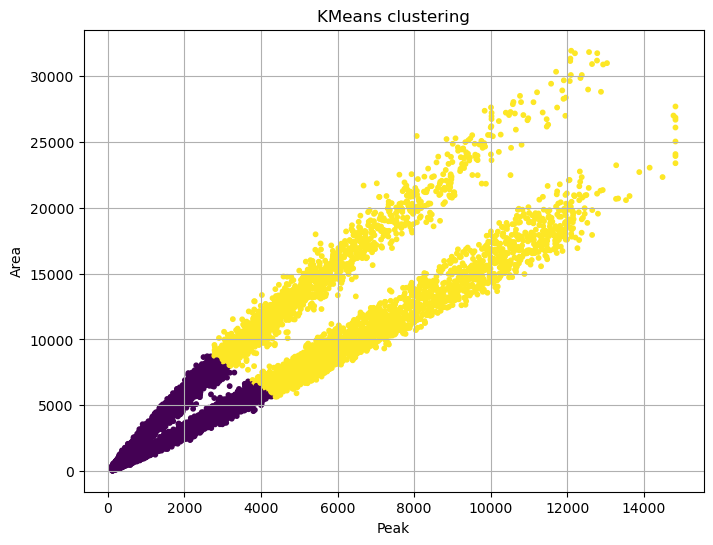

AgglomerativeClustering:
Silhouette score (Agglomerative): 0.7638


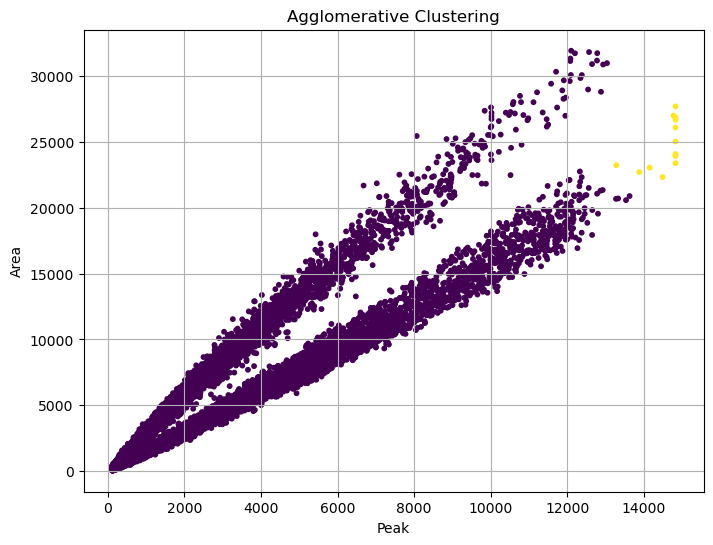

DBSCAN:
Лучшая Silhouette score (DBSCAN): 0.7638 при eps=0.3894736842105263


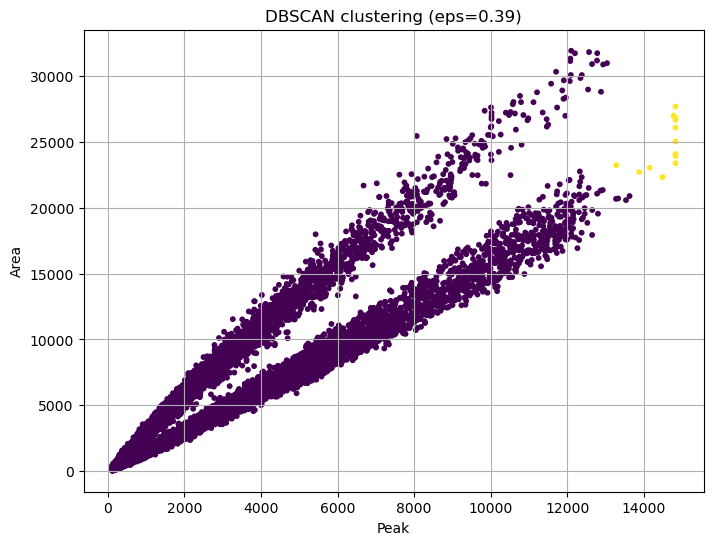

In [17]:
X = features_peak_area[['peak', 'area']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Функция визуализации
def plot_clusters(X, labels, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(title)
    plt.xlabel('Peak')
    plt.ylabel('Area')
    plt.grid(True)
    plt.show()

# KMeans
print("KMeans:")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette score (KMeans): {silhouette_kmeans:.4f}")
plot_clusters(X, kmeans_labels, 'KMeans clustering')

# Agglomerative Clustering
print("AgglomerativeClustering:")
agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
agglo_labels = agglo.fit_predict(X_scaled)
silhouette_agglo = silhouette_score(X_scaled, agglo_labels)
print(f"Silhouette score (Agglomerative): {silhouette_agglo:.4f}")
plot_clusters(X, agglo_labels, 'Agglomerative Clustering')

# DBSCAN — Переберём параметры
print("DBSCAN:")
best_silhouette_dbscan = -1
best_eps = None
best_labels_dbscan = None

for eps in np.linspace(0.3, 2.0, 20):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    if len(set(labels)) > 1 and -1 not in set(labels):  # Проверяем, что не все выбросы
        sil = silhouette_score(X_scaled, labels)
        if sil > best_silhouette_dbscan:
            best_silhouette_dbscan = sil
            best_eps = eps
            best_labels_dbscan = labels

print(f"Лучшая Silhouette score (DBSCAN): {best_silhouette_dbscan:.4f} при eps={best_eps}")
plot_clusters(X, best_labels_dbscan, f'DBSCAN clustering (eps={best_eps:.2f})')


##### По рисункам видно, что Kmeans, DBSCAN и Aglomerative плохо справляются с кластеризацией в данном случае
поэтому применим другой подход

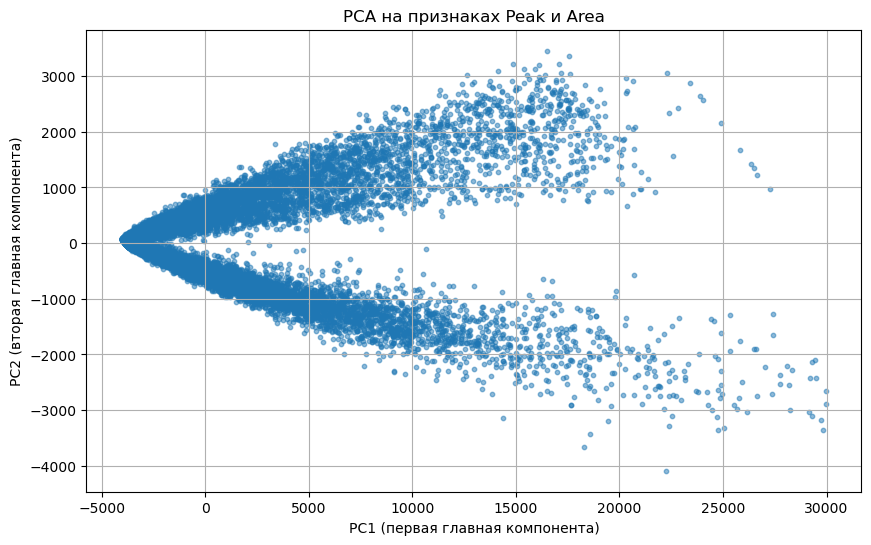

In [18]:
# Будем использовать PCA
X = features_peak_area[['peak', 'area']].values

# Масштабируем признаки 
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# Применяем PCA
pca = PCA(n_components=2)  # 2 компоненты для визуализации
X_pca = pca.fit_transform(X)

# Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.xlabel('PC1 (первая главная компонента)')
plt.ylabel('PC2 (вторая главная компонента)')
plt.title('PCA на признаках Peak и Area')
plt.grid(True)
plt.show()


 #### Рзделим датасет на 2 кластера по второй компоненте, выбрав порог по медиане

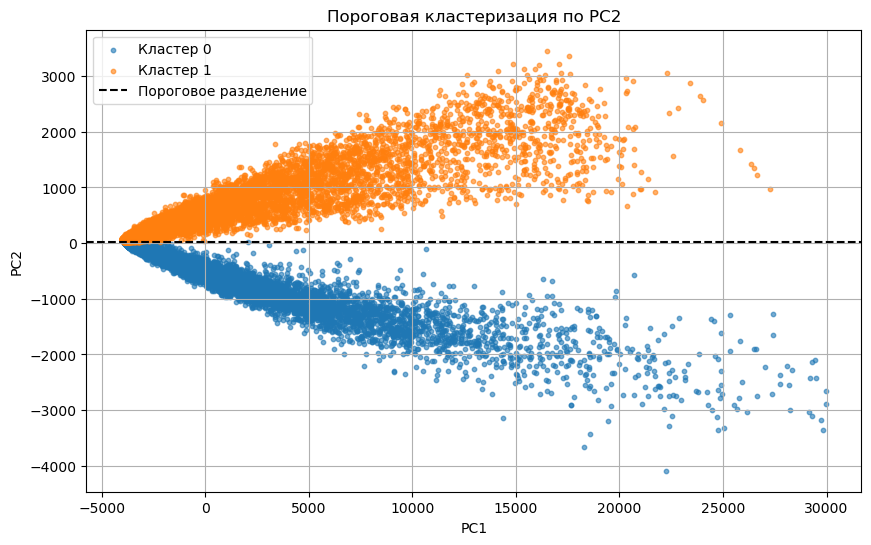

,peak,area,cluster
0,533,1128,0
1,1903,2539,1
2,2560,3436,1
3,566,1261,0
4,1796,2981,1


In [19]:
# Берём данные
X = features_peak_area[['peak', 'area']].values  

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Порог по второй компоненте
thr = np.median(X_pca[:, 1])
cluster_labels_t = (X_pca[:, 1] > thr).astype(int)

# Создаём новый DataFrame
clustered_features = features_peak_area.copy()
clustered_features['cluster'] = cluster_labels_t

# Визуализация
plt.figure(figsize=(10, 6))
for cluster_id in range(2):
    plt.scatter(
        X_pca[:, 0][cluster_labels_t == cluster_id],
        X_pca[:, 1][cluster_labels_t == cluster_id],
        label=f'Кластер {cluster_id}',
        alpha=0.6,
        s=10
    )

plt.axhline(thr, color='black', linestyle='--', label='Пороговое разделение')  
plt.title('Пороговая кластеризация по PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

# Смотрим результат
clustered_features[['peak', 'area', 'cluster']].head()



In [20]:
# Порог
thr

24.51410029522244

#### Пороговая кластеризация — лучшее решение в данном случае,
поскольку что данные фактически одномерные и естественно разделены одной чертой.

##### Теперь объединим датасет с плохими сигналами, отнеся их к третьему кластеру,
 и получившийся датасет с разделенными на 2 кластера хорошими сигналами

In [21]:
features_clustered = clustered_features[['cluster']].copy()

# Подготовим bad_signals
bad_signals_clustered = bad_signals.copy()
# Всем плохим сигналам ставим кластер 2
bad_signals_clustered['cluster'] = 2 
# Оставляем только столбец cluster
bad_signals_clustered = bad_signals_clustered[['cluster']] 

# Объединяем
final_dataset = pd.concat([features_clustered, bad_signals_clustered], axis=0)


final_dataset.head()


,cluster
0,0
1,1
2,1
3,0
4,1


In [22]:
# Сохраняем метки в DataFrame
predictions = pd.DataFrame(final_dataset, columns=['cluster'])
predictions = predictions.reset_index()

# Добавим колонку для новой нумерации
predictions['new_label'] = -1

# Переупорядочим кластеры в порядке появления
unique_labels = predictions['cluster'].drop_duplicates().tolist()
label_map = {label: i for i, label in enumerate(unique_labels)}

# Назначим новые метки
for index, row in predictions.iterrows():
    predictions.loc[index, 'new_label'] = label_map[row['cluster']]

# Оставим только нужные колонки и переименуем
predictions = predictions[['index', 'new_label']]
predictions.columns = ['index', 'cluster']

# Сохраняем результат
predictions.to_csv('submission.csv', index=False)
print("Файл 'submission.csv' сохранён.")

Файл 'submission.csv' сохранён.


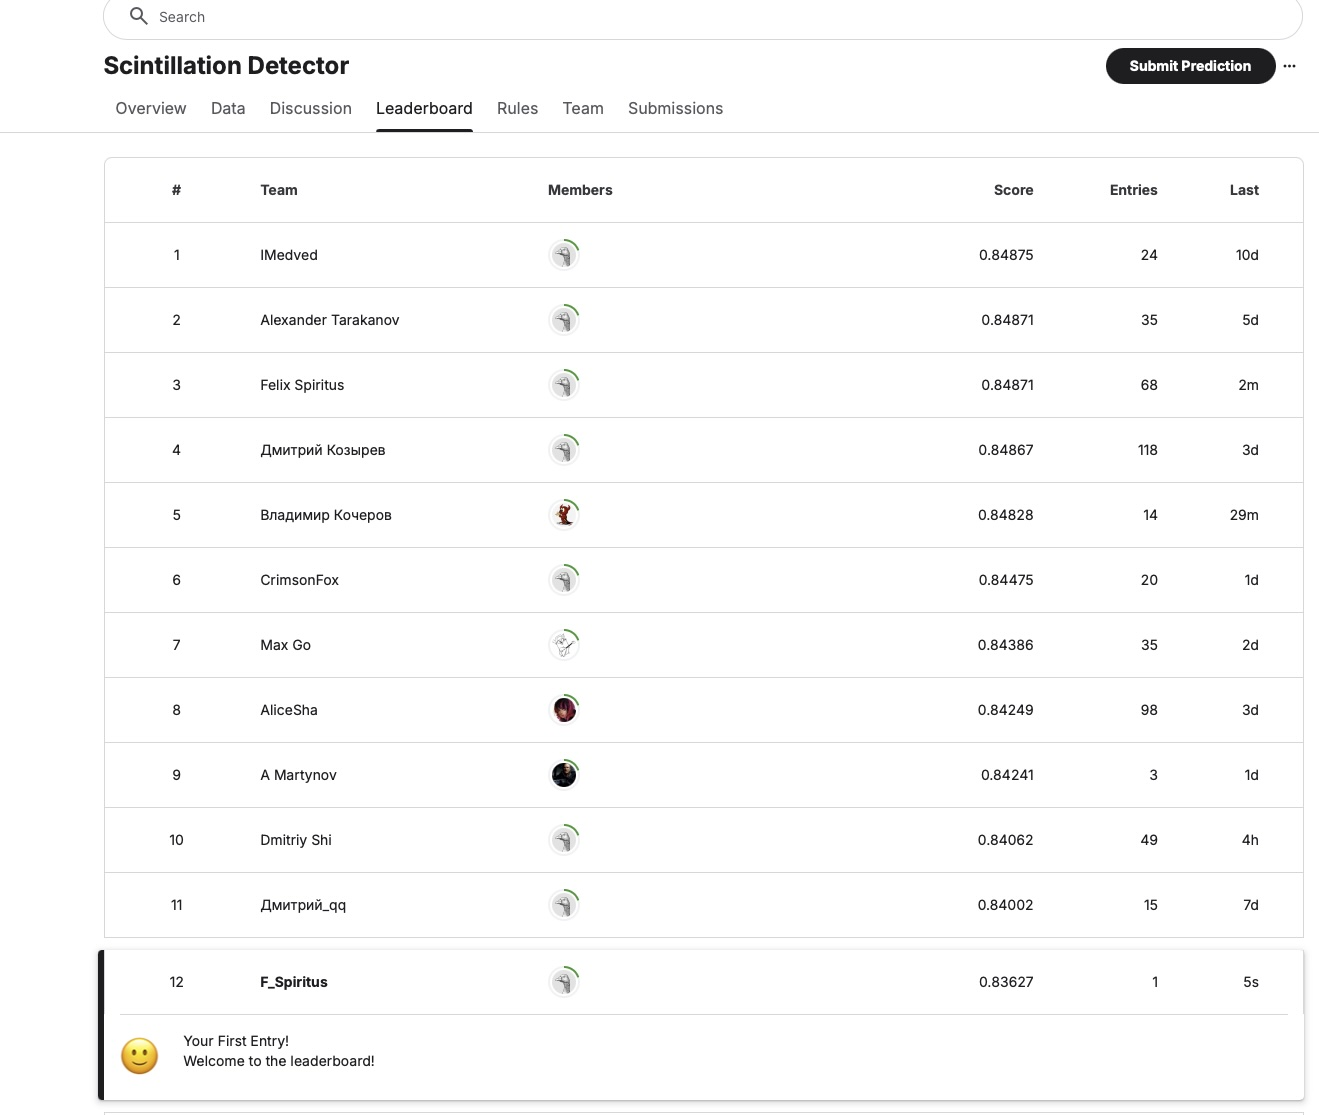

In [23]:
from IPython.display import Image
Image(filename='Detector.jpg')